# alibi — Model-Agnostic KernelShap

[`alibi`](https://github.com/SeldonIO/alibi) is a production-grade XAI toolbox (Seldon) covering counterfactuals, anchors, similarity, prototype, and Shapley-based methods. For the model-agnostic Shapley benchmark we use **`alibi.explainers.KernelShap`** — the same KernelSHAP algorithm as the `shap` library, but with alibi's API and post-processing.

## What this notebook measures

For every (dataset × model) combination in `TrainingConfig.get_all_configs(pytorch=False)` we run KernelShap with a *pinned* coalition budget and record:

| Metric | What it tells us |
|---|---|
| Per-instance wall-clock time (mean ± std over 10 instances) | How runtime scales with feature count when the coalition budget is fixed |
| Top-15 mean \|Shapley value\| | Which features the model relies on most around the explained rows |

## Why pin the coalition budget?

alibi's default `nsamples="auto"` is `2·n_features + 2048`. That makes the budget — and therefore the runtime — a function of the dataset's feature count, so the time we measure on Ames (n=79) is not directly comparable to California (n=8). Pinning `nsamples=2048` removes that dataset-dependent variance: every measurement reflects the same coalition budget, and runtime differences come from the model and feature-count effects on the inner `predict` calls only.

## Scope and limitations

* **Sklearn models only** (`RandomForestRegressor`). Matches Felix's `shap.ipynb` so the two libraries are run on identical models and are directly comparable.
* **Covertype is multiclass classification** but the repo currently trains a `RandomForestRegressor` on its integer class labels (1..7). KernelShap is therefore decomposing the regressed integer score, not a class probability. This is a repo-level shortcut shared with the other notebooks; it's noted again at the call site so readers know what the Covertype numbers actually mean.

In [2]:
from Models.load_and_train import TrainingConfig

# Sklearn models only -- alibi is model-agnostic so we *could* also wrap the
# PyTorch trainer, but keeping pytorch=False here matches shap.ipynb / shapiq.ipynb
# so the three notebooks measure the same model under three different libraries.
all_combi_configs = TrainingConfig.get_all_configs(pytorch=False)
all_trained_models = [config.train(verbose=True) for config in all_combi_configs]

print(f"\nAll {len(all_trained_models)} models trained.")

Trained random_forest_regressor on california_housing
Trained random_forest_regressor on ames_housing
Trained random_forest_regressor on covertype

All 3 models trained.


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from alibi.explainers import KernelShap

# --- Benchmark constants ----------------------------------------------------
# Matches the repo-wide convention established by captum.ipynb / shap.ipynb /
# lightshap.ipynb so results are slot-in comparable across notebooks.
N_BACKGROUND = 100   # marginal-imputer reference distribution (X.iloc[:100])
N_EVAL       = 10    # instances explained per (dataset x model) pair (X.iloc[100:110])
                     # Halved from Felix's N_EVAL=20 because KernelShap is the slowest
                     # model-agnostic method here; 10 still gives a meaningful mean
                     # and std of per-instance runtime without bloating wall-clock.
NSAMPLES     = 2048  # coalitions per instance, pinned (see notebook intro)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Predictor returned a scalar value. Ensure the output represents a probability or decision score as opposed to a classification label!



=== California Housing | random_forest_regressor | n_features=8 | task=regression ===


100%|██████████| 1/1 [00:00<00:00, 10.17it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  6.91it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  7.65it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00, 10.30it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  9.83it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00, 10.10it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00, 10.29it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00

  Per-instance runtime: mean=0.12s, std=0.02s, total=1.15s


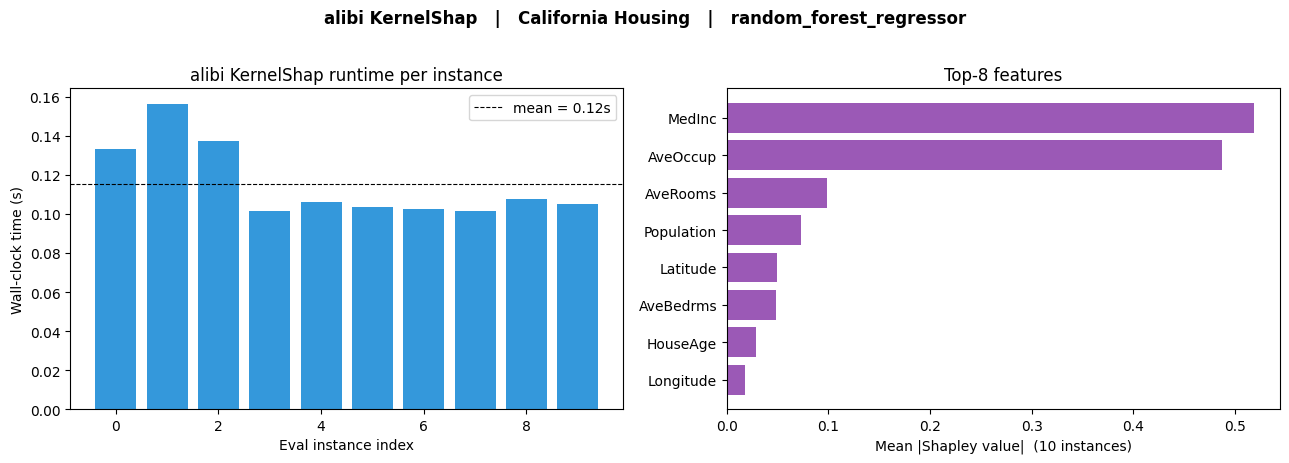

Predictor returned a scalar value. Ensure the output represents a probability or decision score as opposed to a classification label!



=== Ames Housing | random_forest_regressor | n_features=79 | task=regression ===


100%|██████████| 1/1 [00:00<00:00,  1.38it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.21it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.27it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.31it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.21it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.32it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.23it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00

  Per-instance runtime: mean=0.80s, std=0.04s, total=8.03s



X does not have valid feature names, but RandomForestRegressor was fitted with feature names


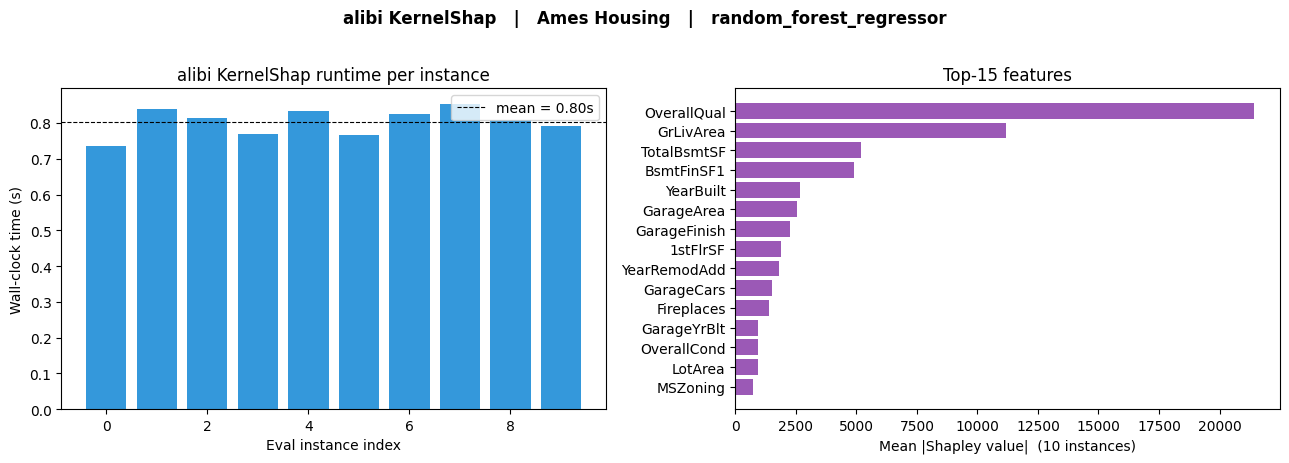

Predictor returned a scalar value. Ensure the output represents a probability or decision score as opposed to a classification label!



=== Forest Covertype | random_forest_regressor | n_features=54 | task=classification ===


100%|██████████| 1/1 [00:00<00:00,  1.11it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.25it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:01<00:00,  1.04s/it]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.05it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.13it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.13it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00<00:00,  1.01it/s]
X does not have valid feature names, but RandomForestRegressor was fitted with feature names
100%|██████████| 1/1 [00:00

  Per-instance runtime: mean=0.92s, std=0.07s, total=9.19s



X does not have valid feature names, but RandomForestRegressor was fitted with feature names


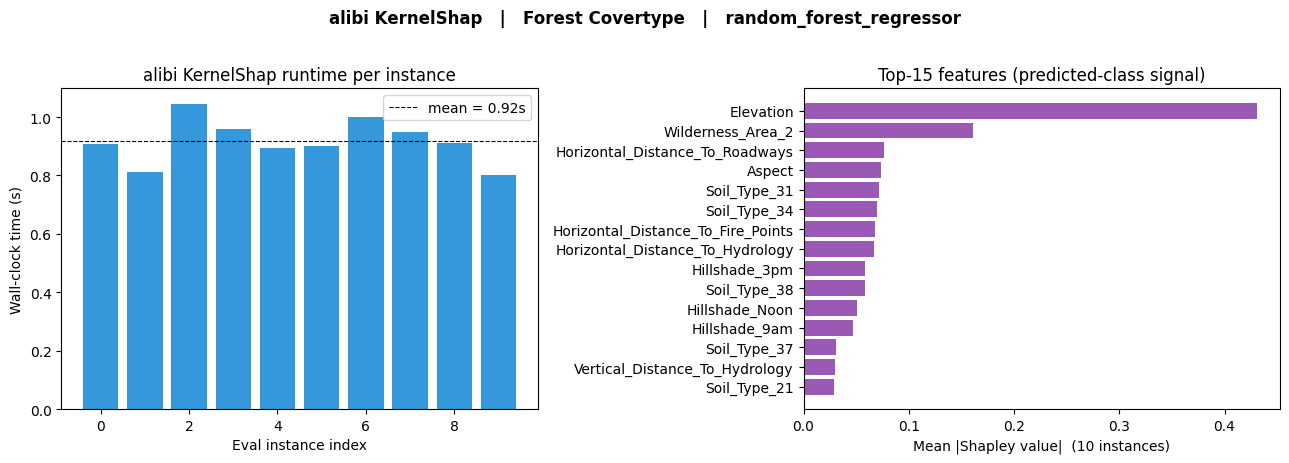

In [4]:
for config, model in zip(all_combi_configs, all_trained_models):
    data = config.dataset.load_dataset()
    X = data["X"]
    feature_names = list(data["feature_names"])
    task = data["task"]
    n_features = len(feature_names)

    X_background = X.iloc[:N_BACKGROUND]
    X_eval       = X.iloc[N_BACKGROUND : N_BACKGROUND + N_EVAL]

    print(f"\n=== {data['name']} | {config.model.value} | n_features={n_features} | task={task} ===")

    # NOTE on Covertype: the repo trains a RandomForestRegressor even when the
    # dataset's task is 'classification', so model.predict returns a float
    # regressed score on the integer class labels 1..7 -- not a probability.
    # We pass model.predict uniformly across all three datasets to stay
    # consistent with shap.ipynb / shapiq.ipynb on this repo. The Covertype
    # numbers should therefore be read as 'what pushes the model's regressed
    # class-index up or down', not as 'what makes class K more probable'.
    predict_fn = model.predict

    explainer = KernelShap(predict_fn, feature_names=feature_names)
    explainer.fit(X_background.values)

    # Per-instance loop (rather than one batched .explain on all 10 rows)
    # so we can report variance across instances. .fit() above amortises the
    # one-time setup cost; per-call cost is dominated by NSAMPLES * predict.
    durations = np.empty(N_EVAL)
    shap_rows = np.empty((N_EVAL, n_features))

    for i in range(N_EVAL):
        x_i = X_eval.iloc[[i]].values
        t0 = time.time()
        exp = explainer.explain(x_i, nsamples=NSAMPLES)
        durations[i] = time.time() - t0
        # alibi returns shap_values as a list (one entry per output dim).
        # Regression / regressed-int-labels -> 1 entry of shape (1, n_features).
        shap_rows[i] = np.asarray(exp.shap_values[0]).reshape(-1)

    print(
        f"  Per-instance runtime: mean={durations.mean():.2f}s, "
        f"std={durations.std():.2f}s, total={durations.sum():.2f}s"
    )

    # --- Plots ------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # (left) per-instance runtime
    axes[0].bar(range(N_EVAL), durations, color="#3498db")
    axes[0].axhline(durations.mean(), color="black", linestyle="--", linewidth=0.8,
                    label=f"mean = {durations.mean():.2f}s")
    axes[0].set_xlabel("Eval instance index")
    axes[0].set_ylabel("Wall-clock time (s)")
    axes[0].set_title("alibi KernelShap runtime per instance")
    axes[0].legend(loc="best")

    # (right) top-15 features by mean |attribution| across the 10 instances
    mean_abs = np.abs(shap_rows).mean(axis=0)
    top_k    = min(15, n_features)
    order    = np.argsort(mean_abs)[::-1][:top_k]
    axes[1].barh(
        [feature_names[k] for k in order[::-1]],
        mean_abs[order[::-1]],
        color="#9b59b6",
    )
    axes[1].set_xlabel(f"Mean |Shapley value|  ({N_EVAL} instances)")
    axes[1].set_title(f"Top-{top_k} features (predicted-class signal)" if task == "classification"
                      else f"Top-{top_k} features")

    plt.suptitle(f"alibi KernelShap   |   {data['name']}   |   {config.model.value}",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()